In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = 'Dataset/titanic.csv'

df = pd.read_csv(data)

In [4]:
df.head()

,PassengerId,Survived,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley",1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath",1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
46,46,0,"Rogers, Mr. William John",3,male,NaN,0,0,S.C./A.4. 23567,8.0500,NaN,S
47,47,0,"Rice, Mrs. William (Margaret Norton)",3,female,NaN,0,0,382652,29.1250,NaN,Q
48,48,1,"Porter, Mr. Henry",1,male,45.0,1,0,110465,83.4750,C6,S
49,49,0,"Skoog, Master. Karl Thorsten",3,male,9.0,1,1,347742,11.1333,NaN,S
50,50,1,"Arnold-Franchi, Mrs. Josef (Josefina Franchi)",3,female,18.0,1,0,349237,17.8000,NaN,S


In [6]:
df.sample(5)

,PassengerId,Survived,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
48,48,1,"Porter, Mr. Henry",1,male,45.0,1,0,110465,83.4750,C6,S
21,22,1,"Beesley, Mr. Lawrence",2,male,34.0,0,0,248698,13.0000,D56,S
12,13,0,"Saundercock, Mr. William Henry",3,male,20.0,0,0,A/5. 2151,8.0500,NaN,S
41,41,0,"Hansen, Mr. Claus Peter",3,male,NaN,0,0,350029,7.8542,NaN,S
11,12,1,"Bonnell, Miss. Elizabeth",1,female,58.0,0,0,113783,26.5500,C103,S


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (51, 12)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  51 non-null     int64  
 1   Survived     51 non-null     int64  
 2   Name         51 non-null     object 
 3   Pclass       51 non-null     int64  
 4   Sex          51 non-null     object 
 5   Age          39 non-null     float64
 6   SibSp        51 non-null     int64  
 7   Parch        51 non-null     int64  
 8   Ticket       51 non-null     object 
 9   Fare         51 non-null     float64
 10  Cabin        12 non-null     object 
 11  Embarked     51 non-null     object 
dtypes: float64(2), int64(5), object(5)
memory usage: 4.9+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,51.000000,51.000000,51.000000,39.000000,51.000000,51.000000,51.000000
mean,25.607843,0.509804,2.392157,26.897436,0.549020,0.470588,30.392565
std,14.451406,0.504878,0.826521,16.624007,0.923336,1.083567,42.919982
min,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,7.225000
25%,13.500000,0.000000,2.000000,14.500000,0.000000,0.000000,8.050000
50%,26.000000,1.000000,3.000000,27.000000,0.000000,0.000000,17.800000
75%,37.500000,1.000000,3.000000,36.500000,1.000000,0.500000,29.597900
max,50.000000,1.000000,3.000000,58.000000,4.000000,5.000000,263.000000


In [10]:
df.size

612

In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df.isnull().sum()

PassengerId     0
Survived        0
Name            0
Pclass          0
Sex             0
Age            12
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin          39
Embarked        0
dtype: int64

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))

Cabin          76.470588
Age            23.529412
PassengerId     0.000000
Survived        0.000000
Name            0.000000
Pclass          0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.000000
dtype: float64


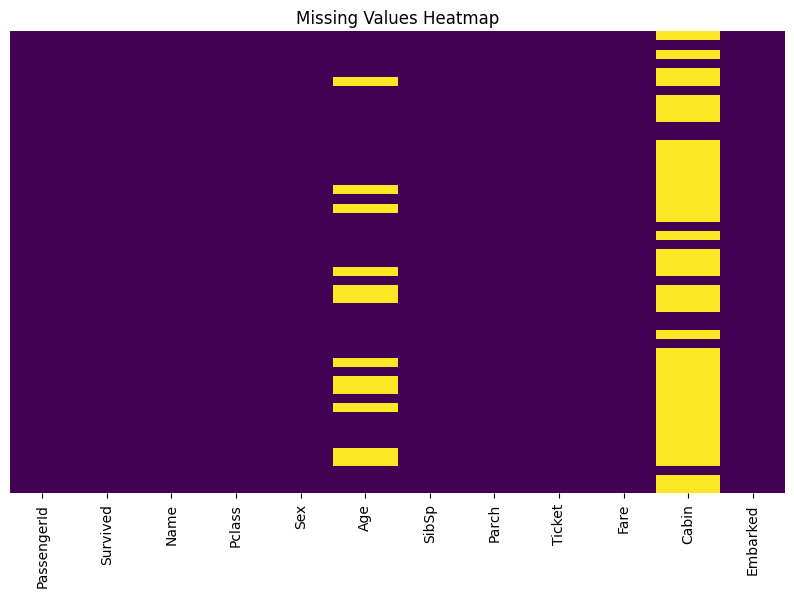

In [14]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [15]:
# Fill Age missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked missing values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill Cabin missing values
df["Cabin"] = df["Cabin"].fillna("Unknown")

print(df.isnull().sum())

PassengerId    0
Survived       0
Name           0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [16]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [18]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (51, 12)


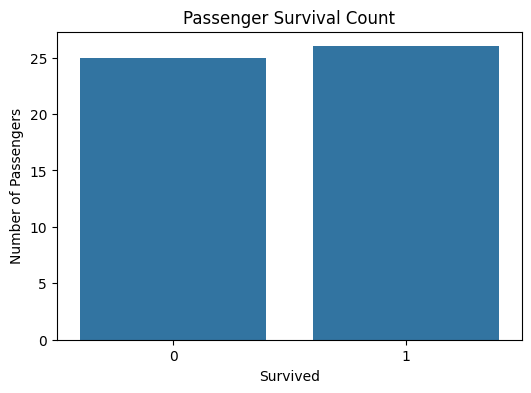

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

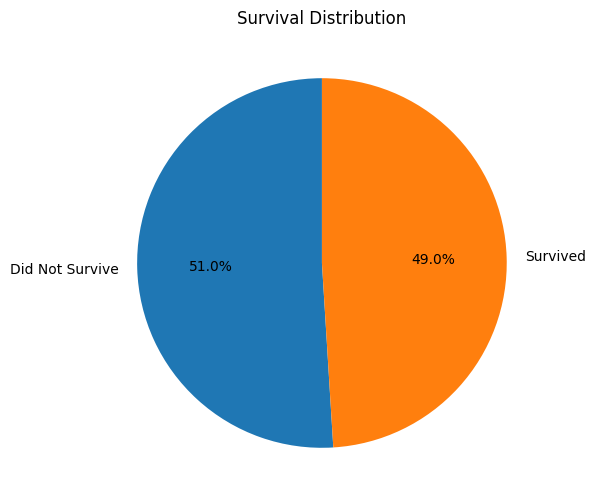

In [20]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Survival Distribution")

plt.show()

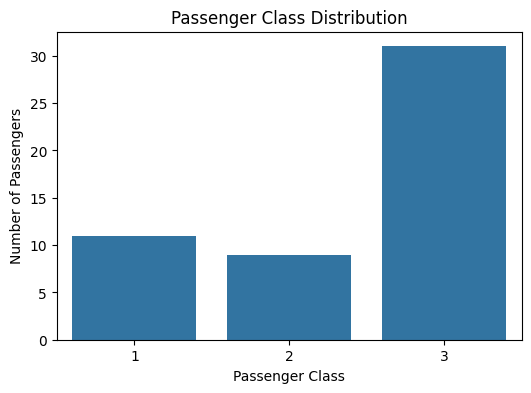

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

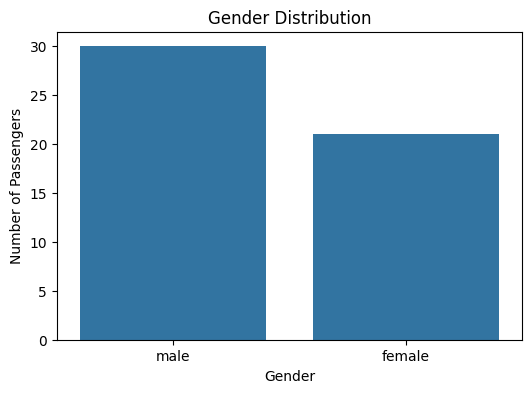

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

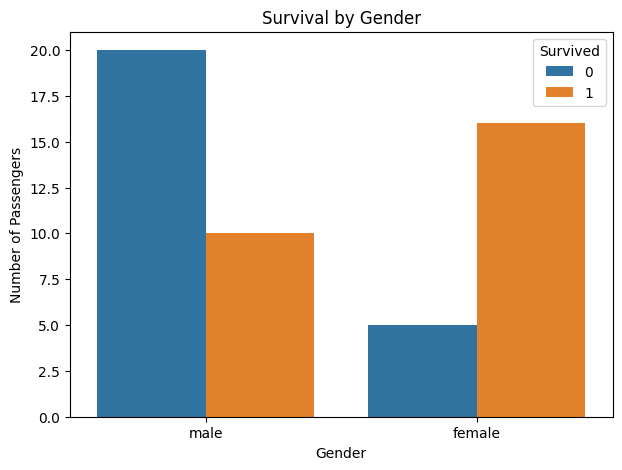

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

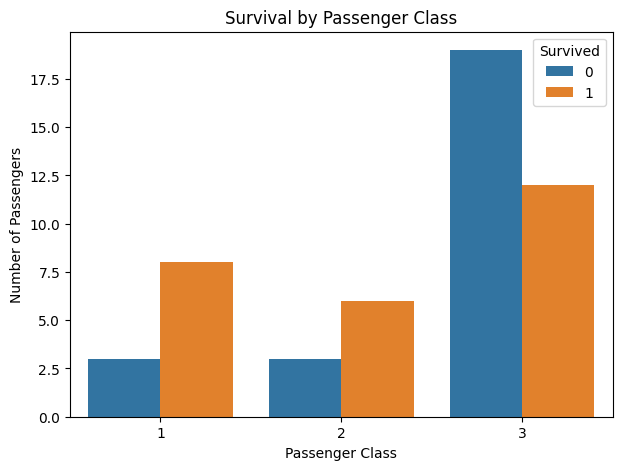

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

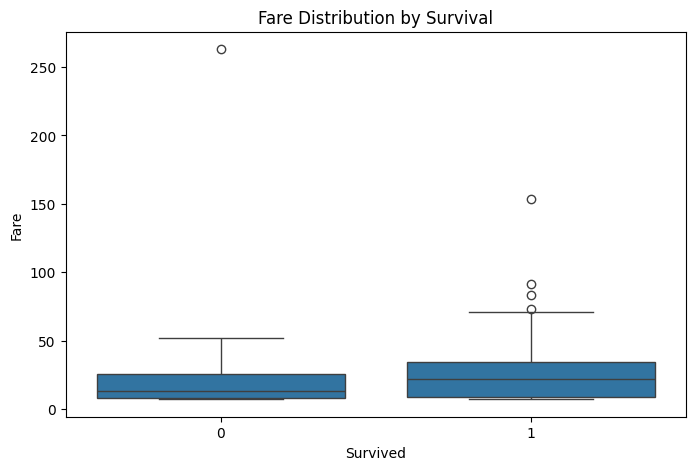

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

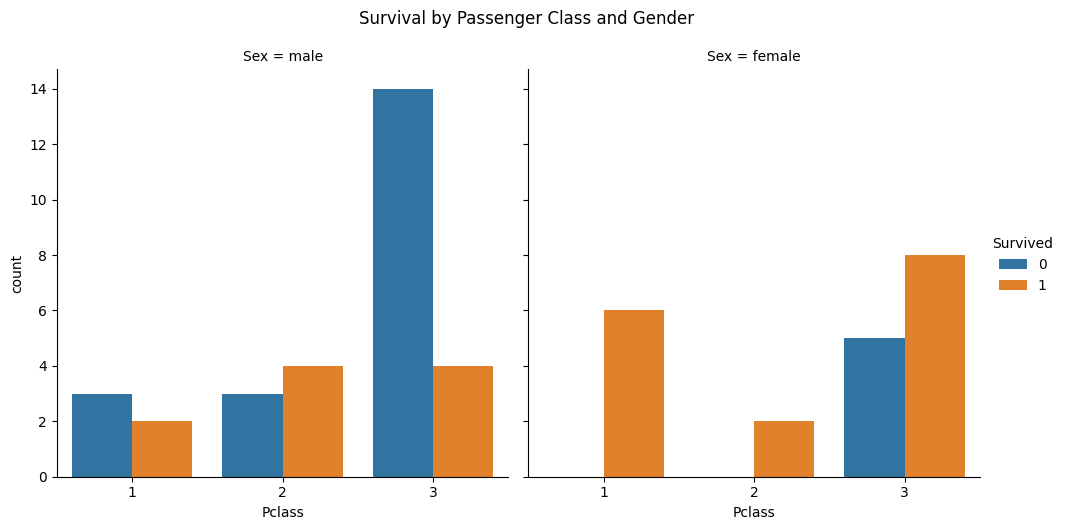

In [26]:
g = sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Sex",
    kind="count",
    height=5,
    aspect=1
)

g.fig.suptitle(
    "Survival by Passenger Class and Gender",
    y=1.05
)

plt.show()

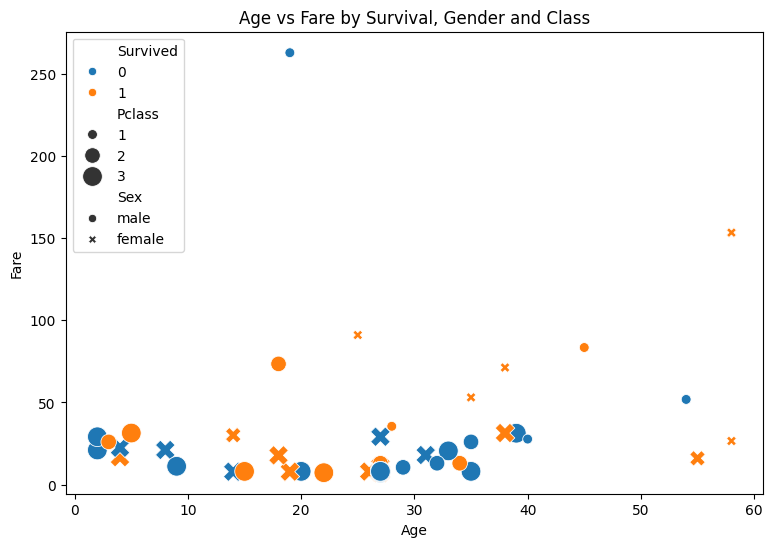

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    style="Sex",
    size="Pclass",
    sizes=(50, 200)
)

plt.title("Age vs Fare by Survival, Gender and Class")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.296966  0.139509 -0.140485 -0.045160  0.078461
Pclass   -0.296966  1.000000 -0.548373  0.026721  0.214121 -0.589761
Age       0.139509 -0.548373  1.000000 -0.448088 -0.119867  0.158006
SibSp    -0.140485  0.026721 -0.448088  1.000000  0.376284  0.364084
Parch    -0.045160  0.214121 -0.119867  0.376284  1.000000  0.156113
Fare      0.078461 -0.589761  0.158006  0.364084  0.156113  1.000000


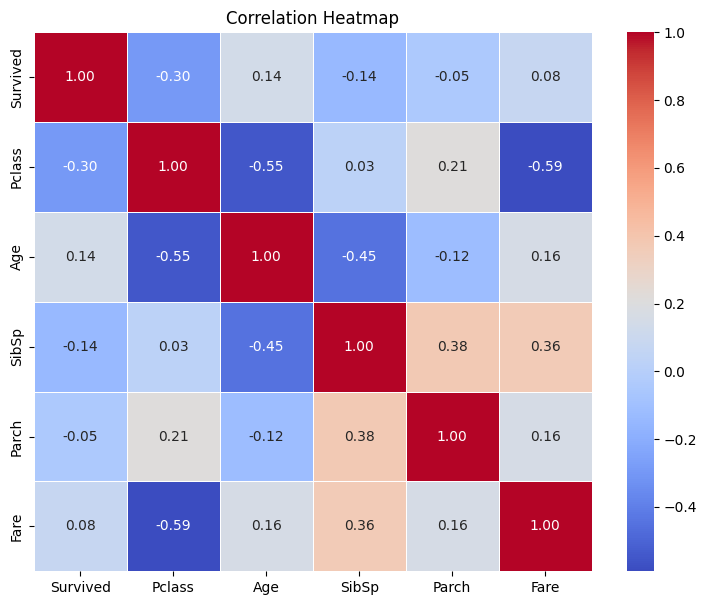

In [29]:
numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlation = df[numeric_columns].corr()

print(correlation)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()